<a href="https://colab.research.google.com/github/gregblast-bot/AutoMagic_Detection/blob/main/MagicCardDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAGIC CARD ORGANIZER TRAINING**
We are going to try to train the data on google collab because why not learn a new skill today.

Below is the definition of functions

# Functions

In [9]:
# ------------------------------------------------
# --- IMPORTS
# ------------------------------------------------
import os
import sys
import requests
import time
import math
import random
import json
from pathlib import Path
from io import BytesIO
from PIL import Image, ImageDraw, ImageFont, ImageFilter  # NEW — added ImageDraw, ImageFilter for synthetic generation
import numpy as np
import cv2
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from IPython.display import display, Javascript, HTML
import matplotlib.pyplot as plt
from google.colab.output import eval_js
import base64

import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# ------------------------------------------------
# --- CONFIG
# ------------------------------------------------
NUM_CARD_IMAGES   = 5_000    # Scryfall bulk download target
NUM_OTHER_IMAGES  = 5_000    # Synthetic non-card images
IMAGE_SIZE        = 96        # All images will be resized to this size
BATCH_SIZE        = 32        # Number of images to train on at once
NUM_CHANNELS      = 1
DOWNLOAD_THREADS  = 16        # NEW — parallel download workers for card images
SCRYFALL_DELAY    = 0.05      # NEW — delay per request

# ------------------------------------------------
# --- PATHS
# ------------------------------------------------
DATA_DIR = Path("/content/mtg_dataset")
CARD_DIR = DATA_DIR / "card"
NOT_CARD_DIR = DATA_DIR / "not_card"
MODEL_DIR = Path("/content/model_output")
AUGMENTED_CARD_DIR = DATA_DIR / "augmented"


# ------------------------------------------------
# --- FUNCTIONS
# ------------------------------------------------

# Supports bulk urls
def fetch_scryfall_bulk_urls(num_cards=NUM_CARD_IMAGES):
    """
    Use Scryfall's bulk-data endpoint to get image URLs for up to num_cards.
    This avoids hammering the /cards/random endpoint one-by-one.

    Returns a list of (index, image_url) tuples.
    """
    print("Fetching Scryfall bulk data catalog...")
    bulk_resp = requests.get(
        "https://api.scryfall.com/bulk-data",
        headers={"User-Agent": "MTGCardDetector/1.0"},
        timeout=30,
    )
    bulk_resp.raise_for_status()
    bulk_list = bulk_resp.json()["data"]

    # Find the "default_cards" bulk file (smallest complete set)
    default_bulk = None
    for entry in bulk_list:
        if entry["type"] == "default_cards":
            default_bulk = entry
            break

    if not default_bulk:
        # Fallback to oracle_cards if default not found
        for entry in bulk_list:
            if entry["type"] == "oracle_cards":
                default_bulk = entry
                break

    if not default_bulk:
        raise RuntimeError("Could not find a suitable bulk data source on Scryfall")

    download_uri = default_bulk["download_uri"]
    print(f"Downloading bulk JSON from: {download_uri}")
    print(f"  (This is a large file — may take 1-3 minutes)")

    bulk_data_resp = requests.get(
        download_uri,
        headers={"User-Agent": "MTGCardDetector/1.0"},
        timeout=300,
        stream=True,
    )
    bulk_data_resp.raise_for_status()

    # Parse the JSON — this is the big operation
    print("Parsing bulk JSON...")
    all_cards = json.loads(bulk_data_resp.content)
    print(f"  Total cards in Scryfall database: {len(all_cards)}")

    # Extract image URLs, preferring "small" size for speed/storage
    url_list = []
    for card in all_cards:
        img_url = None

        # Standard cards
        image_uris = card.get("image_uris")
        if image_uris:
            img_url = image_uris.get("small") or image_uris.get("normal")

        # Double-faced / multi-face cards — take front face
        if not img_url:
            faces = card.get("card_faces", [])
            if faces and "image_uris" in faces[0]:
                img_url = faces[0]["image_uris"].get("small") or faces[0]["image_uris"].get("normal")

        if img_url:
            url_list.append(img_url)

    print(f"  Found {len(url_list)} cards with image URLs")

    # Shuffle and trim to requested count
    random.shuffle(url_list)
    url_list = url_list[:num_cards]

    return list(enumerate(url_list))


def _download_single_card(args):
    """Worker function for threaded card download."""
    idx, url = args
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content)).convert("RGB")
        img.save(CARD_DIR / f"card_{idx:06d}.jpg")
        return True
    except Exception:
        return False


def fetch_scryfall_cards(num_cards=NUM_CARD_IMAGES):
    """
    Download MTG card images using bulk data + parallel downloads.
    Much faster than one-by-one random API calls.
    """
    # Step 1: Get all URLs from bulk data
    indexed_urls = fetch_scryfall_bulk_urls(num_cards)
    total = len(indexed_urls)
    print(f"\nDownloading {total} card images with {DOWNLOAD_THREADS} threads...")

    # Step 2: Parallel download
    downloaded = 0
    errors = 0
    start_time = time.time()

    with ThreadPoolExecutor(max_workers=DOWNLOAD_THREADS) as executor:
        futures = {executor.submit(_download_single_card, item): item for item in indexed_urls}

        for future in as_completed(futures):
            if future.result():
                downloaded += 1
            else:
                errors += 1

            done = downloaded + errors
            if done % 1000 == 0:
                elapsed = time.time() - start_time
                rate = done / elapsed if elapsed > 0 else 0
                eta = (total - done) / rate if rate > 0 else 0
                print(f"  Progress: {done}/{total} ({downloaded} ok, {errors} err) "
                      f"— {rate:.0f} img/s, ETA {eta/60:.1f} min")

    elapsed = time.time() - start_time
    print(f"\nDone! Downloaded {downloaded} card images in {elapsed/60:.1f} min "
          f"({errors} errors)")
    return downloaded

def fetch_non_card_images(num_images=NUM_OTHER_IMAGES):
  """
  Download random non-card images for negative samples.
  """

  print(f"Fetching {num_images} non-card images...")
  downloaded = 0
  errors = 0
  max_errors = 50

  while downloaded < num_images and errors < max_errors:
      try:
          # Picsum returns a random image at the requested size
          resp = requests.get(
              f"https://picsum.photos/146/204",  # Similar aspect ratio to MTG cards
              timeout=10,
          )
          resp.raise_for_status()

          img = Image.open(BytesIO(resp.content)).convert("RGB")
          img.save(NOT_CARD_DIR / f"other_{downloaded:04d}.jpg")
          downloaded += 1
          errors = 0

          if downloaded % 50 == 0:
              print(f"  Downloaded {downloaded}/{num_images} non-card images")

          time.sleep(0.3)

      except Exception as e:
          errors += 1
          if errors % 10 == 0:
              print(f"  Warning: {errors} errors so far. Last: {e}")
          time.sleep(0.5)

  print(f"Downloaded {downloaded} non-card images ({errors} final error count)")
  return downloaded

TensorFlow version: 2.19.0


In [10]:

# ------------------------------------------------
# --- AUGMENTATION PARAMETERS
# ------------------------------------------------
PERSPECTIVE_INTENSITY = 0.3
BRIGHTNESS_MAX_DELTA = 0.3
BLUR_MAX_KERNEL = 7
NOISE_FACTOR = 0.05


# ------------------------------------------------
# --- AUGMENTATION FUNCTIONS
# ------------------------------------------------
def perspective_warp_cv(image_np):
    h, w = image_np.shape[:2]
    max_shift = int(min(h, w) * PERSPECTIVE_INTENSITY)
    if max_shift < 2:
        return image_np

    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    def _shift():
        return random.randint(max_shift // 2, max_shift)

    style = random.choice(["top_narrow", "bottom_narrow", "left_narrow", "right_narrow"])

    if style == "top_narrow":
        dst = np.float32([[_shift(), _shift()], [w - _shift(), _shift()], [w, h], [0, h]])
    elif style == "bottom_narrow":
        dst = np.float32([[0, 0], [w, 0], [w - _shift(), h - _shift()], [_shift(), h - _shift()]])
    elif style == "left_narrow":
        dst = np.float32([[_shift(), _shift()], [w, 0], [w, h], [_shift(), h - _shift()]])
    else:
        dst = np.float32([[0, 0], [w - _shift(), _shift()], [w - _shift(), h - _shift()], [0, h]])

    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(image_np, M, (w, h),
                                borderMode=cv2.BORDER_CONSTANT,
                                borderValue=(0, 0, 0))

def adjust_brightness(image_np):
    img_tensor = tf.image.random_brightness(image_np, max_delta=BRIGHTNESS_MAX_DELTA)
    img_tensor = tf.clip_by_value(img_tensor, 0, 255)

    return img_tensor.numpy().astype(np.uint8)

def gaussian_blur(image_np):
    k = random.choice([3, 5, 7])
    k = min(k, BLUR_MAX_KERNEL)

    return cv2.GaussianBlur(image_np, (k, k), 0)

def add_noise(image_np):
    img_float = image_np.astype(np.float32) / 255.0
    noise = tf.random.normal(shape=img_float.shape, mean=0.0, stddev=NOISE_FACTOR)
    noisy = tf.clip_by_value(img_float + noise, 0.0, 1.0)

    return (noisy.numpy() * 255).astype(np.uint8)

# ------------------------------------------------
# --- Create the dataset here
# ------------------------------------------------

# Set the operations for the card creation set
operations = [
    perspective_warp_cv,
    adjust_brightness,
    gaussian_blur,
    add_noise,
    ]

def generate_augmented_dataset(augments_per_image=3):
    """
    For each image in CARD_DIR, apply a random subset of operations
    and save the results to AUGMENTED_CARD_DIR.
    """

    AUGMENTED_CARD_DIR.mkdir(parents=True, exist_ok=True)

    image_paths = list(CARD_DIR.glob("*.jpg"))
    print(f"Augmenting {len(image_paths)} images, {augments_per_image}x each...")

    count = 0
    for img_path in image_paths:
        img = cv2.imread(str(img_path))
        if img is None: # image read failed
            continue

        for i in range(augments_per_image):
            augmented = img.copy()

            # Pick a random number of operations
            num_ops = random.randint(1, len(operations))
            chosen_ops = random.sample(operations, num_ops)

            for op in chosen_ops:
                augmented = op(augmented)

            out_name = f"{img_path.stem}_aug{i:02d}.jpg"
            cv2.imwrite(str(CARD_DIR / out_name), augmented)
            count += 1

    print(f"Saved {count} augmented images to {CARD_DIR}")
    return count

# Download

---



In [11]:
# Clean out old data
for d in [CARD_DIR, NOT_CARD_DIR]:
    if d.exists():
        shutil.rmtree(d)

# Create directories for storage of the data
CARD_DIR.mkdir(parents=True, exist_ok=True)
NOT_CARD_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Run downloads and create the base dataset
cards_downloaded = fetch_scryfall_cards()
non_cards_downloaded = fetch_non_card_images()

Fetching Scryfall bulk data catalog...
  (This is a large file — may take 1-3 minutes)
Parsing bulk JSON...
  Total cards in Scryfall database: 113773
  Found 113611 cards with image URLs

  Progress: 1000/5000 (1000 ok, 0 err) — 133 img/s, ETA 0.5 min
  Progress: 2000/5000 (2000 ok, 0 err) — 131 img/s, ETA 0.4 min
  Progress: 3000/5000 (3000 ok, 0 err) — 129 img/s, ETA 0.3 min
  Progress: 4000/5000 (4000 ok, 0 err) — 116 img/s, ETA 0.1 min
  Progress: 5000/5000 (5000 ok, 0 err) — 114 img/s, ETA 0.0 min

Done! Downloaded 5000 card images in 0.7 min (0 errors)
Fetching 5000 non-card images...
  Downloaded 50/5000 non-card images
  Downloaded 100/5000 non-card images
  Downloaded 150/5000 non-card images
  Downloaded 200/5000 non-card images
  Downloaded 250/5000 non-card images
  Downloaded 300/5000 non-card images
  Downloaded 350/5000 non-card images
  Downloaded 400/5000 non-card images
  Downloaded 450/5000 non-card images
  Downloaded 500/5000 non-card images
  Downloaded 550/5000 

# Generator dataset

---

In [12]:
# create the transformed data set
generate_augmented_dataset()

Augmenting 5000 images, 3x each...
Saved 15000 augmented images to /content/mtg_dataset/card


15000

# Camera

In [13]:
# simple camera function - not going to lie, AI helped me. idk Javascript
# to stop the camera - right like the video -> more controls -> pause key

test_js = Javascript('''
  async function testCamera() {
    try {
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      const video = document.createElement('video');
      video.srcObject = stream;
      video.autoplay = true;
      video.style.width = '320px';
      document.body.appendChild(video);
      return "SUCCESS: camera opened";
    } catch (err) {
      return "ERROR: " + err.name + " - " + err.message;
    }
  }
''')

display(test_js)
result = eval_js('testCamera()')
print(result)

<IPython.core.display.Javascript object>

ERROR: NotAllowedError - Permission denied


# Display

---

In [14]:
def show_augmented_samples(num_samples=5):
    """
    Show original cards next to their augmented versions.
    """

    originals = [p for p in CARD_DIR.glob("*.jpg") if "_aug" not in p.stem]
    num_samples = min(num_samples, len(originals))
    samples = random.sample(originals, num_samples)

    fig, axes = plt.subplots(num_samples, 2, figsize=(6, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    for row, path in enumerate(samples):
        img = cv2.imread(str(path))
        if img is None:
            continue

        # Left: original
        axes[row][0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row][0].set_title("Original", fontsize=9)

        # Right: find a matching augmented version
        aug_paths = list(CARD_DIR.glob(f"{path.stem}_aug*.jpg"))
        if aug_paths:
            aug_img = cv2.imread(str(random.choice(aug_paths)))
            axes[row][1].imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
            axes[row][1].set_title("Augmented", fontsize=9)
        else:
            axes[row][1].set_title("No augment found", fontsize=9)

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle("Before and After Augmentation", fontsize=14)
    plt.tight_layout()
    plt.show()

def show_non_card_samples(num_samples=10):
    """
    Display a grid of downloaded non-card images.
    """

    images = list(NOT_CARD_DIR.glob("*.jpg"))
    num_samples = min(num_samples, len(images))
    samples = random.sample(images, num_samples)

    cols = 5
    rows = (num_samples + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if num_samples > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < len(samples):
            img = cv2.imread(str(samples[i]))
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(samples[i].name, fontsize=8)
        ax.axis('off')

    plt.suptitle(f"Non-Card Samples ({len(images)} total)", fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
def display_simple():
  """
  Display a random card and its augmented version.
  """

  card_images = list(CARD_DIR.glob("*.jpg"))
  img = Image.open(random.choice(card_images))
  display(img)

  img_np = np.array(img.convert("L"))
  img_np = cv2.resize(img_np, (IMAGE_SIZE, IMAGE_SIZE))
  warped = perspective_warp_cv(img_np)

  display(Image.fromarray(warped))

# Main

---

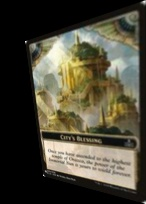

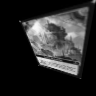

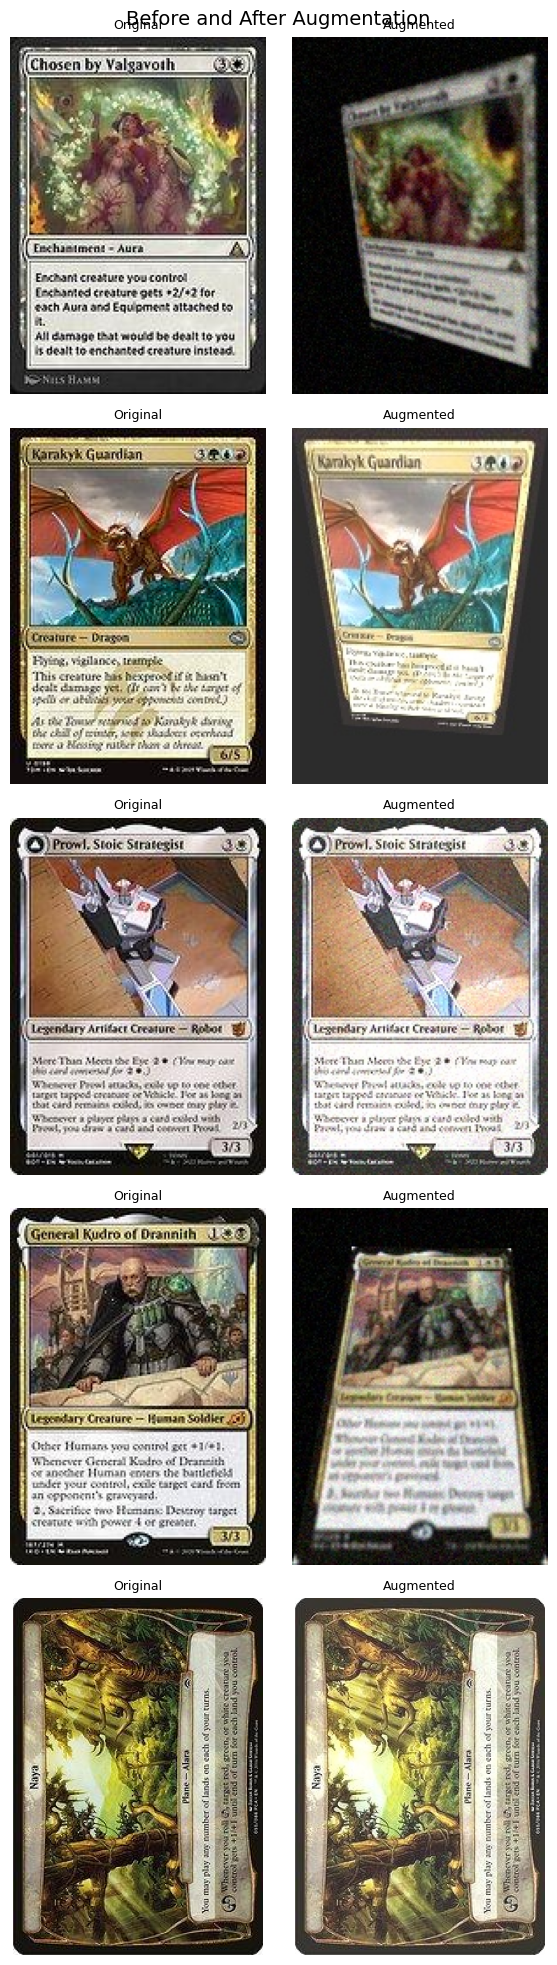

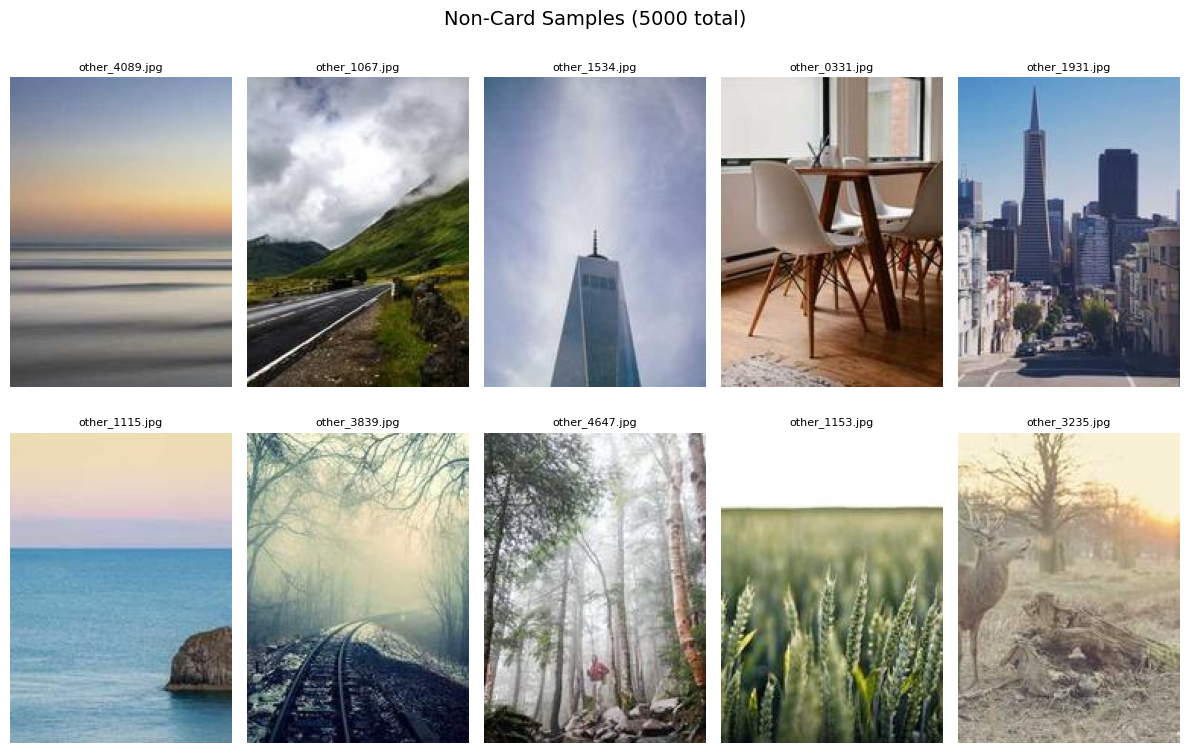

In [16]:
# simple display of the before and after of the sample
display_simple()
show_augmented_samples()
show_non_card_samples()


# Data Preperation

---

In [18]:
# Load images from folders
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

# Rescale pixels from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 25000 files belonging to 3 classes.
Using 20000 files for training.
Found 25000 files belonging to 3 classes.
Using 5000 files for validation.


# Define TinyConv Model

---

In [19]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1)),

    # First Convolution: Find edges/corners
    tf.keras.layers.Conv2D(8, (3, 3), strides=(2, 2), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolution: Find card shapes
    tf.keras.layers.Conv2D(16, (3, 3), strides=(2, 2), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),

    # Flatten and Classify (0 = Not Card, 1 = Card)
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 12, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,305 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,617 (14.13 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 32 (128.00 B)

# Model Accuracy (before quantization)

---

In [20]:
# Evaluate the original float model on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"Baseline Float Model Accuracy: {accuracy * 100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7784 - loss: 0.6427
Baseline Float Model Accuracy: 77.84%


# Define TinyConv Model

---

In [21]:
# Export as a standard TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset needed for full integer quantization
def representative_data_gen():
  for input_value, _ in train_ds.take(100):
    yield [input_value]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

# Save the model
with open('mtg_detector.tflite', 'wb') as f:
  f.write(tflite_model_int8)

Saved artifact at '/tmp/tmpbfppssd5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139895334885648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334885456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334883536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334883152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139895334886608: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


# Model Accuracy (after quantization)

---

In [22]:
def evaluate_tflite_model(tflite_model_path, dataset):
    # Load the TFLite model and allocate tensors
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    correct_predictions = 0
    total_predictions = 0

    # Iterate through the validation dataset
    for images, labels in dataset:
        for i in range(len(images)):
            # TFLite INT8 models expect data in a specific range and type
            input_data = images[i:i+1].numpy()

            # If the model is quantized to INT8, rescale/cast the input
            if input_details['dtype'] == np.int8:
                scale, zero_point = input_details['quantization']
                input_data = input_data / scale + zero_point
                input_data = input_data.astype(np.int8)

            interpreter.set_tensor(input_details['index'], input_data)
            interpreter.invoke()

            # Get the output and compare to label
            output = interpreter.get_tensor(output_details['index'])
            prediction = 1 if output[0][0] > 0 else 0 # Adjust threshold if using INT8 output

            if prediction == labels[i].numpy():
                correct_predictions += 1
            total_predictions += 1

    return correct_predictions / total_predictions

# Run the evaluation
quantized_accuracy = evaluate_tflite_model('mtg_detector.tflite', val_ds)
print(f"Quantized TFLite Model Accuracy: {quantized_accuracy * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Quantized TFLite Model Accuracy: 77.12%


# Convert to C Array

---

In [23]:
!apt-get update && apt-get install xxd
!xxd -i mtg_detector.tflite > mtg_model_data.cc

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,929 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,9

# Compare Metrics

---

In [24]:
def get_file_size(file_path):
    size = os.path.getsize(file_path)
    return size / 1024  # Size in KB

# Assuming you saved the baseline Keras model
model.save("baseline_model.h5")

print("--- Final Comparison ---")
print(f"Baseline Accuracy:  {accuracy * 100:.2f}%")
print(f"Quantized Accuracy: {quantized_accuracy * 100:.2f}%")
print(f"Accuracy Drop:      {(accuracy - quantized_accuracy) * 100:.2f}%")
print("------------------------")
print(f"Baseline Size:      {get_file_size('baseline_model.h5'):.2f} KB")
print(f"Quantized Size:     {get_file_size('mtg_detector.tflite'):.2f} KB")

--- Final Comparison ---
Baseline Accuracy:  77.84%
Quantized Accuracy: 77.12%
Accuracy Drop:      0.72%
------------------------
Baseline Size:      46.77 KB
Quantized Size:     8.01 KB
